Table of contents
* 1. Pre-processing
   * 1.1 Import packages
   * 1.2 Set up Data Augmentation
   * 1.3 Split into Training & Testing sets
<br>
<br>
* 2. Modeling
    * 2.1 ResNet Model
    * 2.2 EfficientNet Model- Basic
    * 2.3 EfficientNet Model- Tuning
<br>
<br>
* 3. Calibration and Threshold Tuning 
   * 3.1 Temperature Scaling
   * 3.2 Threshold Tuning
   * 3.3 Sample Predictions
<br>
<br>
* 4. Analyzing results 

# 1. Pre-processing

1.1 Import packages

In [1]:
# Import packages
import os
import pandas as pd
import numpy as np

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets, models
import torch.optim as optim
from PIL import Image
from transformers import ViTForImageClassification, ViTImageProcessor
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import confusion_matrix, precision_score, recall_score, fbeta_score
import time
import random

In [14]:
#Set up Reproducibility 
import multiprocessing
multiprocessing.set_start_method("spawn", force=True)

SEED = 42

#Set seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

#Make Python hashing deterministic
os.environ["PYTHONHASHSEED"] = str(SEED)

#DataLoader worker seeding
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)



In [3]:
#setup directory
data_dir = "./tpc-imgs"

1.2 Set up Data Augmentation

In [4]:
IMG_SIZE = 224

# Data Augmentation for training set

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomApply([transforms.RandomAffine(0, shear=2)], p=0.15),
    transforms.RandomApply([transforms.RandomPerspective(distortion_scale=0.05)], p=0.10),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])


])

# Data Augmentation for testing set
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


1.3 Split into Training & Testing sets

In [19]:
# Load full dataset
full_dataset = datasets.ImageFolder(root=data_dir)

# Split indices
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

# setup DataLoaders
g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, worker_init_fn=seed_worker, generator=g)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g)

device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Modeling

2.1 ResNet Model

In [20]:
# Setup resnet model
modelR = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze backbone
for param in modelR.parameters():
    param.requires_grad = False

# Replace classifier head
num_features = modelR.fc.in_features
modelR.fc = nn.Linear(num_features, 2)

modelR.to(device)

# Set Criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelR.fc.parameters(), lr=1e-4)


In [21]:
# Run resnet model
epochs = 5 #initially ran 15 but switched to 5 for rerun to cut down on time

total_start = time.time()

for epoch in range(epochs):
    epoch_start = time.time()
    modelR.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = modelR(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

    # Validation
    modelR.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = modelR(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Compute metrics
    cm = confusion_matrix(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f2 = fbeta_score(all_labels, all_preds, beta=2)

    accuracy = (all_preds == all_labels).mean()

    print(f"Validation Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F2 Score:  {f2:.4f}")

    # Timing summary for this epoch
    epoch_time = time.time() - epoch_start
    total_time = time.time() - total_start
    remaining = (total_time / (epoch + 1)) * (epochs - epoch - 1)
    print(f"Epoch Time: {epoch_time/60:.2f} min | "
          f"Total Elapsed: {total_time/60:.2f} min | "
          f"Est. Remaining: {remaining/60:.2f} min")
    print("-" * 50)

Epoch 1/5 - Loss: 0.7016
Validation Accuracy: 0.6208
Confusion Matrix:
 [[598 381]
 [374 638]]
Recall:    0.6304
Precision: 0.6261
F2 Score:  0.6296
Epoch Time: 5.05 min | Total Elapsed: 5.05 min | Est. Remaining: 20.21 min
--------------------------------------------------
Epoch 2/5 - Loss: 0.6428
Validation Accuracy: 0.6635
Confusion Matrix:
 [[687 292]
 [378 634]]
Recall:    0.6265
Precision: 0.6847
F2 Score:  0.6373
Epoch Time: 4.94 min | Total Elapsed: 9.99 min | Est. Remaining: 14.98 min
--------------------------------------------------
Epoch 3/5 - Loss: 0.6145
Validation Accuracy: 0.6881
Confusion Matrix:
 [[666 313]
 [308 704]]
Recall:    0.6957
Precision: 0.6922
F2 Score:  0.6950
Epoch Time: 4.67 min | Total Elapsed: 14.66 min | Est. Remaining: 9.77 min
--------------------------------------------------
Epoch 4/5 - Loss: 0.5961
Validation Accuracy: 0.6966
Confusion Matrix:
 [[584 395]
 [209 803]]
Recall:    0.7935
Precision: 0.6703
F2 Score:  0.7653
Epoch Time: 4.68 min | Tot

2.2 EfficientNet Model- Basic

In [22]:
# Setup efficientnet model
modelE = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze backbone
for param in modelE.parameters():
    param.requires_grad = False

# Replace classifier
num_features = modelE.classifier[1].in_features
modelE.classifier[1] = nn.Linear(num_features, 2)

modelE.to(device)

# Set Criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelE.classifier[1].parameters(), lr=1e-4)

In [23]:
#Run efficientnet model
total_start = time.time()

for epoch in range(5): #Initially ran 15 but switched to 5 for rerun to cut down on time
    epoch_start = time.time()
    modelE.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = modelE(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

    # Validation
    modelE.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = modelE(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Compute metrics
    cm = confusion_matrix(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f2 = fbeta_score(all_labels, all_preds, beta=2)

    accuracy = (all_preds == all_labels).mean()

    print(f"Validation Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F2 Score:  {f2:.4f}")

    # Timing summary for this epoch
    epoch_time = time.time() - epoch_start
    total_time = time.time() - total_start
    remaining = (total_time / (epoch + 1)) * (epochs - epoch - 1)
    print(f"Epoch Time: {epoch_time/60:.2f} min | "
          f"Total Elapsed: {total_time/60:.2f} min | "
          f"Est. Remaining: {remaining/60:.2f} min")
    print("-" * 50)

Epoch 1/5 - Loss: 0.6718
Validation Accuracy: 0.6414
Confusion Matrix:
 [[562 417]
 [297 715]]
Recall:    0.7065
Precision: 0.6316
F2 Score:  0.6902
Epoch Time: 4.75 min | Total Elapsed: 4.75 min | Est. Remaining: 19.00 min
--------------------------------------------------
Epoch 2/5 - Loss: 0.6250
Validation Accuracy: 0.6936
Confusion Matrix:
 [[705 274]
 [336 676]]
Recall:    0.6680
Precision: 0.7116
F2 Score:  0.6763
Epoch Time: 4.63 min | Total Elapsed: 9.38 min | Est. Remaining: 14.06 min
--------------------------------------------------
Epoch 3/5 - Loss: 0.6060
Validation Accuracy: 0.7142
Confusion Matrix:
 [[710 269]
 [300 712]]
Recall:    0.7036
Precision: 0.7258
F2 Score:  0.7079
Epoch Time: 4.61 min | Total Elapsed: 13.99 min | Est. Remaining: 9.32 min
--------------------------------------------------
Epoch 4/5 - Loss: 0.5881
Validation Accuracy: 0.7112
Confusion Matrix:
 [[731 248]
 [327 685]]
Recall:    0.6769
Precision: 0.7342
F2 Score:  0.6876
Epoch Time: 4.59 min | Tot

2.3 EfficientNet Model- Tuning

In [24]:
# Create Functions for use in tuning better efficientNet Model

def mixup_data(x, y, alpha=0.4):
    """ Perform Mixup augmentation on a batch of images and labels."""
    
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    return mixed_x, y, y[index], lam


def cutmix_data(x, y, alpha=0.4):
    """ Perform CutMix augmentation on a batch of images and labels."""
    
    lam = np.random.beta(alpha, alpha)
    batch_size, _, h, w = x.size()
    index = torch.randperm(batch_size).to(x.device)

    cut_w = int(w * np.sqrt(1 - lam))
    cut_h = int(h * np.sqrt(1 - lam))

    cx = np.random.randint(w)
    cy = np.random.randint(h)

    x1 = np.clip(cx - cut_w // 2, 0, w)
    x2 = np.clip(cx + cut_w // 2, 0, w)
    y1 = np.clip(cy - cut_h // 2, 0, h)
    y2 = np.clip(cy + cut_h // 2, 0, h)

    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]

    lam = 1 - ((x2 - x1) * (y2 - y1) / (w * h))
    return x, y, y[index], lam


def mixup_cutmix_criterion(criterion, preds, y_a, y_b, lam):
    """Compute the loss for Mixup or CutMix augmented samples."""
    
    return lam * criterion(preds, y_a) + (1 - lam) * criterion(preds, y_b)


def compute_metrics(model, dataloader, device, toxic_class=1):
    """Compute confusion matrix, precision, recall, and F2 score for a model.
       Runs the model on the provided dataloader and collects predictions and labels to compute classification metrics."""
    
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, pos_label=toxic_class)
    precision = precision_score(all_labels, all_preds, pos_label=toxic_class)
    f2 = fbeta_score(all_labels, all_preds, beta=2, pos_label=toxic_class)

    return cm, precision, recall, f2


# Training Loop
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    """Train the model for a single epoch with optional Mixup/CutMix augmentation.
       Randomly applies Mixup or CutMix to each batch with equal probability.
       Computes loss, performs backpropagation, and tracks accuracy."""
    
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        rand_val = np.random.rand()

        if rand_val < 0.25:
            images_mixed, y_a, y_b, lam = mixup_data(images, labels)
            outputs = model(images_mixed)
            loss = mixup_cutmix_criterion(criterion, outputs, y_a, y_b, lam)

        elif rand_val < 0.50:
            images_mixed, y_a, y_b, lam = cutmix_data(images, labels)
            outputs = model(images_mixed)
            loss = mixup_cutmix_criterion(criterion, outputs, y_a, y_b, lam)

        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


# Validation Loop
def validate(model, dataloader, criterion, device):
    """Evaluate the model on a validation dataset.
       Computes loss and accuracy without performing gradient updates."""
    
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [25]:
# Setup efficientnet model
modelE2 = models.efficientnet_b0(weights="IMAGENET1K_V1")
num_features = modelE2.classifier[1].in_features
modelE2.classifier[1] = nn.Linear(num_features, len(full_dataset.classes))

modelE2 = modelE2.to(device)

# Set Criterion
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.3]).to(device), label_smoothing=0.05)


In [26]:
# Run EfficientNet Model
# Phase 1 - Train classifier Head
for param in modelE2.features.parameters():
    param.requires_grad = False

optimizer = optim.Adam(modelE2.classifier[1].parameters(), lr=2e-4)

def warmup(epoch):
    """Linear warmup schedule for learning rate scaling.
       Gradually increases the learning rate during the first few epochs
       to stabilize early training."""
    
    return min(1.0, (epoch + 1) / 3)

warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=3, eta_min=1e-6)

print("=== Phase 1: Training classifier head ===")
phase1_start = time.time()
for epoch in range(6):
    epoch_start = time.time()
    train_loss, train_acc = train_one_epoch(modelE2, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(modelE2, val_loader, criterion, device)

    if epoch < 3:
        warmup_scheduler.step()
    else:
        cosine_scheduler.step()

    cm, precision, recall, f2 = compute_metrics(modelE2, val_loader, device)

    print(f"\nEpoch {epoch+1}/6 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F2 Score:  {f2:.4f}")

    epoch_time = time.time() - epoch_start
    total_time = time.time() - phase1_start
    remaining = (total_time / (epoch + 1)) * (6 - epoch - 1)
    print(f"Epoch Time: {epoch_time/60:.2f} min | "
          f"Total Elapsed: {total_time/60:.2f} min | "
          f"Est. Remaining: {remaining/60:.2f} min")
    print("-" * 50)

print(f"=== Phase 1 Complete | Total Time: {(time.time() - phase1_start)/60:.2f} min ===")

# Phase 2 - Unfreeze Top 30%
for name, param in modelE2.named_parameters():
    if "blocks.5" in name or "blocks.6" in name:
        param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, modelE2.parameters()), lr=3e-5)
warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda e: min(1.0, (e+1)/2))
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=2, eta_min=1e-6)

print("\n=== Phase 2: Unfreezing top layers ===")
phase2_start = time.time()

for epoch in range(4):
    epoch_start = time.time()
    train_loss, train_acc = train_one_epoch(modelE2, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(modelE2, val_loader, criterion, device)

    if epoch < 2:
        warmup_scheduler.step()
    else:
        cosine_scheduler.step()

    cm, precision, recall, f2 = compute_metrics(modelE2, val_loader, device)

    print(f"\nEpoch {epoch+1}/4 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F2 Score:  {f2:.4f}")

    epoch_time = time.time() - epoch_start
    total_time = time.time() - phase2_start
    remaining = (total_time / (epoch + 1)) * (4 - epoch - 1)
    print(f"Epoch Time: {epoch_time/60:.2f} min | "
          f"Total Elapsed: {total_time/60:.2f} min | "
          f"Est. Remaining: {remaining/60:.2f} min")
    print("-" * 50)

print(f"=== Phase 2 Complete | Total Time: {(time.time() - phase2_start)/60:.2f} min ===")

# Phase 3 - Full Fine Tune
for param in modelE2.parameters():
    param.requires_grad = True

optimizer = optim.Adam(modelE2.parameters(), lr=1e-5)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=10, eta_min=5e-6)

print("\n=== Phase 3: Full fine-tuning ===")
phase3_start = time.time()

for epoch in range(10):
    epoch_start = time.time()
    train_loss, train_acc = train_one_epoch(modelE2, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(modelE2, val_loader, criterion, device)

    cosine_scheduler.step()

    cm, precision, recall, f2 = compute_metrics(modelE2, val_loader, device)

    print(f"\nEpoch {epoch+1}/10 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print("Confusion Matrix:\n", cm)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F2 Score:  {f2:.4f}")

    epoch_time = time.time() - epoch_start
    total_time = time.time() - phase3_start
    remaining = (total_time / (epoch + 1)) * (10 - epoch - 1)
    print(f"Epoch Time: {epoch_time/60:.2f} min | "
          f"Total Elapsed: {total_time/60:.2f} min | "
          f"Est. Remaining: {remaining/60:.2f} min")
    print("-" * 50)

print(f"=== Phase 3 Complete | Total Time: {(time.time() - phase3_start)/60:.2f} min ===")

=== Phase 1: Training classifier head ===

Epoch 1/6 | Train Acc: 0.5424 | Val Acc: 0.6138
Confusion Matrix:
 [[399 580]
 [189 823]]
Recall:    0.8132
Precision: 0.5866
F2 Score:  0.7549
Epoch Time: 5.43 min | Total Elapsed: 5.43 min | Est. Remaining: 27.17 min
--------------------------------------------------

Epoch 2/6 | Train Acc: 0.6072 | Val Acc: 0.6595
Confusion Matrix:
 [[447 532]
 [146 866]]
Recall:    0.8557
Precision: 0.6195
F2 Score:  0.7951
Epoch Time: 5.42 min | Total Elapsed: 10.85 min | Est. Remaining: 21.70 min
--------------------------------------------------

Epoch 3/6 | Train Acc: 0.6444 | Val Acc: 0.7147
Confusion Matrix:
 [[597 382]
 [186 826]]
Recall:    0.8162
Precision: 0.6838
F2 Score:  0.7858
Epoch Time: 5.42 min | Total Elapsed: 16.27 min | Est. Remaining: 16.27 min
--------------------------------------------------

Epoch 4/6 | Train Acc: 0.6534 | Val Acc: 0.7182
Confusion Matrix:
 [[583 396]
 [165 847]]
Recall:    0.8370
Precision: 0.6814
F2 Score:  0.800

In [27]:
torch.save(modelE2.state_dict(), "model_final.pth")
print("Saved model to model_final.pth")

Saved model to model_final.pth


# 3. Calibration and Threshold Tuning

3.1 Temperature Scaling

In [28]:
%%time
# Model calibration using temperature scaling

class ModelWithTemperature(nn.Module):
    """Wrapper module that adds a learnable temperature parameter for post-training calibration.
       Temperature scaling adjusts the confidence of logits without changing the model's predicted class ordering."""
    
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.0)

    def forward(self, x):
        logits = self.model(x)
        return logits / self.temperature


def calibrate_temperature(model, dataloader, device):
    """Fit a temperature parameter to calibrate model confidence.
       Uses validation logits and labels to optimize temperature."""
    
    model.eval()
    nll_criterion = nn.CrossEntropyLoss()

    logits_list, labels_list = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            logits_list.append(logits)
            labels_list.append(labels)

    logits = torch.cat(logits_list)
    labels = torch.cat(labels_list)

    temp_model = ModelWithTemperature(model).to(device)
    optimizer = optim.LBFGS([temp_model.temperature], lr=0.01, max_iter=50)

    def eval_closure():
        optimizer.zero_grad()
        loss = nll_criterion(logits / temp_model.temperature, labels)
        loss.backward()
        return loss

    optimizer.step(eval_closure)
    return temp_model

print("\n=== Calibrating model with temperature scaling ===")
modelE2 = calibrate_temperature(modelE2, val_loader, device)
print("Learned temperature:", modelE2.temperature.item())


# Threshold tuning on calibrated model
def tune_threshold(model, dataloader, device, toxic_class=1):
    """Find the optimal classification threshold based on F2 score.
       Sweeps thresholds from 0.10 to 0.90 and selects the one that maximizes the F2 score, which emphasizes recall."""
    
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)[:, toxic_class]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = torch.tensor(all_probs).numpy()
    all_labels = torch.tensor(all_labels).numpy()

    best_t, best_f2, best_recall = 0.5, -1.0, -1.0
    for t in [i / 100 for i in range(10, 91, 2)]:  # 0.10 to 0.90 step 0.02
        preds = (all_probs >= t).astype(int)
        recall = recall_score(all_labels, preds, pos_label=toxic_class)
        f2 = fbeta_score(all_labels, preds, beta=2, pos_label=toxic_class)
        if f2 > best_f2:
            best_f2, best_t, best_recall = f2, t, recall

    return best_t, best_f2, best_recall

best_t, best_f2, best_recall = tune_threshold(modelE2, val_loader, device)
print(f"\n=== Threshold tuning (calibrated model) ===")
print(f"Best threshold: {best_t:.2f}")
print(f"Best F2:        {best_f2:.4f}")
print(f"Recall at best: {best_recall:.4f}")




=== Calibrating model with temperature scaling ===
Learned temperature: 0.8283184170722961

=== Threshold tuning (calibrated model) ===
Best threshold: 0.28
Best F2:        0.9051
Recall at best: 0.9664
CPU times: total: 10min
Wall time: 1min 39s


In [29]:
with open("temperature.txt", "w") as f:
    f.write(str(modelE2.temperature.item()))
print("Saved temperature to temperature.txt")


Saved temperature to temperature.txt


In [30]:
%%time
#load model to apply calibration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ModelWithTemperature(nn.Module):
    """Wrapper module that adds the fixed learned temperature parameter above"""
    def __init__(self, model, temperature):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.tensor([temperature]))

    def forward(self, x):
        logits = self.model(x)
        return logits / self.temperature



# Load Trained model and apply calibration

# Load EfficientNet-B0 architecture
model = models.efficientnet_b0(weights=None)

# Replace classifier head
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)   # toxic vs clean

# Load trained weights
model.load_state_dict(torch.load("model_final.pth", map_location=device))

# Wrap with temperature scaling
temperature = modelE2.temperature.item()
model = ModelWithTemperature(model, temperature).to(device)
model.eval()


# Preprocessing Pipeline
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
])


CPU times: total: 281 ms
Wall time: 255 ms


3.2 Threshold Tuning

In [31]:
def collect_logits_and_labels(model, dataloader, device):
    """Run model to return logits + labels."""
    model.eval()
    all_logits, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            logits = model(images)
            all_logits.append(logits.cpu())
            all_labels.append(labels)

    return torch.cat(all_logits), torch.cat(all_labels)

def compute_threshold_metrics(logits, labels, thresholds):
    """Compute precision, recall, and F2 for a list of thresholds."""
    probs = torch.softmax(logits, dim=1)[:, 1].numpy()
    labels = labels.numpy()

    precisions, recalls, f2_scores = [], [], []

    for t in thresholds:
        preds = (probs >= t).astype(int)
        precisions.append(precision_score(labels, preds, zero_division=0))
        recalls.append(recall_score(labels, preds))
        f2_scores.append(fbeta_score(labels, preds, beta=2))

    return precisions, recalls, f2_scores

In [32]:
%%time
import matplotlib.pyplot as plt

# 1. Collect logits once
logits, labels = collect_logits_and_labels(modelE2, val_loader, device)

# 2. Apply temperature scaling
T = modelE2.temperature.item()
logits_eval = logits / T
#logits_eval = logits #use this variable to test model without applying temperature scaling

# 3. Define thresholds for plotting
thresholds_plot = np.linspace(0.05, 0.95, 37)

# 4. Compute metrics for plot
precisions, recalls, f2_scores = compute_threshold_metrics(
    logits_eval, labels, thresholds_plot)


CPU times: total: 4min 56s
Wall time: 49.7 s


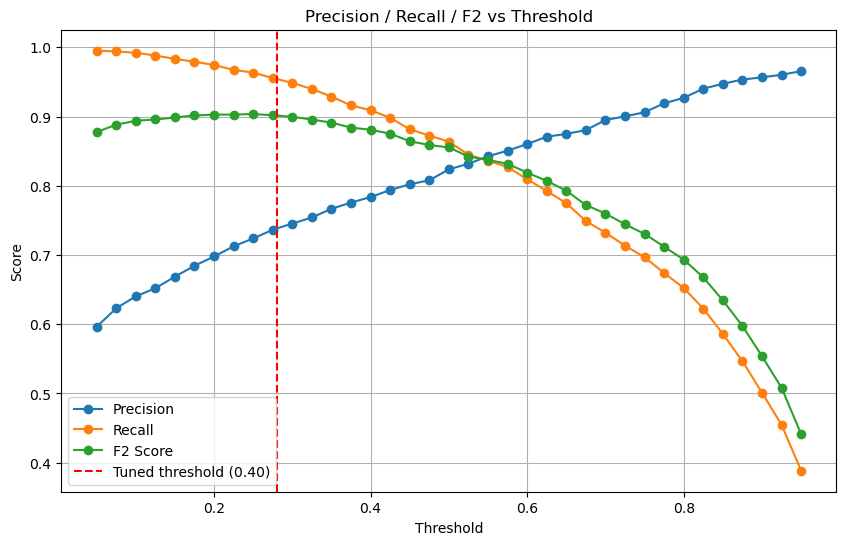

In [53]:
# 5. Plot metrics
plt.figure(figsize=(10,6))
plt.plot(thresholds_plot, precisions, label="Precision", marker="o")
plt.plot(thresholds_plot, recalls, label="Recall", marker="o")
plt.plot(thresholds_plot, f2_scores, label="F2 Score", marker="o")

plt.axvline(0.28, color="red", linestyle="--", label="Tuned threshold (0.40)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F2 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
best_idx = np.argmax(f2_scores)
print(f"Best F2 threshold: {thresholds_plot[best_idx]:.2f} | F2={f2_scores[best_idx]:.4f}")

# Find thresholds where precision >= 0.70 AND recall >= 0.90
candidates = [
    (t, p, r) for t, p, r in zip(thresholds_plot, precisions, recalls)
    if p >= 0.7000 and r >= 0.8999
]

if candidates:
    print("\nBalanced thresholds (precision ≥ 0.7000 and recall ≥ 0.9000):")
    for t, p, r in candidates:
        print(f"Threshold {t:.2f} | Recall={r:.4f} | Precision={p:.4f}")
else:
    print("\nNo threshold meets precision ≥ 0.7000 and recall ≥ 0.9000 simultaneously.")

Best F2 threshold: 0.25 | F2=0.9036

Balanced thresholds (precision ≥ 0.7000 and recall ≥ 0.9000):
Threshold 0.22 | Recall=0.9674 | Precision=0.7125
Threshold 0.25 | Recall=0.9634 | Precision=0.7238
Threshold 0.27 | Recall=0.9555 | Precision=0.7365
Threshold 0.30 | Recall=0.9486 | Precision=0.7453
Threshold 0.32 | Recall=0.9397 | Precision=0.7542
Threshold 0.35 | Recall=0.9289 | Precision=0.7667
Threshold 0.37 | Recall=0.9160 | Precision=0.7757
Threshold 0.40 | Recall=0.9091 | Precision=0.7836


In [35]:
# Loop through thresholds .20 - .50 to receive metrics

thresholds_zoom = [round(t, 2) for t in np.arange(0.20, 0.50, 0.02)]

probs = torch.softmax(logits_eval, dim=1)[:, 1].numpy()
labels_np = labels.numpy()

for th in thresholds_zoom:
    preds = (probs >= th).astype(int)

    cm = confusion_matrix(labels_np, preds)
    precision = precision_score(labels_np, preds, zero_division=0)
    recall = recall_score(labels_np, preds)
    f2 = fbeta_score(labels_np, preds, beta=2)

    print(f"Threshold: {th:.2f}")
    print("Confusion Matrix:\n", cm)
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F2: {f2:.4f}")
    print("-" * 40)


Threshold: 0.20
Confusion Matrix:
 [[552 427]
 [ 26 986]]
Precision: 0.6978 | Recall: 0.9743 | F2: 0.9028
----------------------------------------
Threshold: 0.22
Confusion Matrix:
 [[576 403]
 [ 30 982]]
Precision: 0.7090 | Recall: 0.9704 | F2: 0.9037
----------------------------------------
Threshold: 0.24
Confusion Matrix:
 [[598 381]
 [ 34 978]]
Precision: 0.7196 | Recall: 0.9664 | F2: 0.9044
----------------------------------------
Threshold: 0.26
Confusion Matrix:
 [[619 360]
 [ 40 972]]
Precision: 0.7297 | Recall: 0.9605 | F2: 0.9033
----------------------------------------
Threshold: 0.28
Confusion Matrix:
 [[633 346]
 [ 47 965]]
Precision: 0.7361 | Recall: 0.9536 | F2: 0.9004
----------------------------------------
Threshold: 0.30
Confusion Matrix:
 [[651 328]
 [ 52 960]]
Precision: 0.7453 | Recall: 0.9486 | F2: 0.8996
----------------------------------------
Threshold: 0.32
Confusion Matrix:
 [[668 311]
 [ 57 955]]
Precision: 0.7543 | Recall: 0.9437 | F2: 0.8986
------------

3.3 Sample Predictions

In [36]:
# function to predict image toxicity

THRESHOLD = 0.28   # tuned threshold (picked for recall above 95%, f2 above 90%, Presision above 70% and FN below 50)

def predict_image(image_path):
    """Predict toxicity for a single image using the tuned threshold."""
    
    img = Image.open(image_path).convert("RGB")
    x = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]

    toxic_prob = probs[1].item()
    prediction = 1 if toxic_prob >= THRESHOLD else 0

    return {
        "prediction": "TOXIC" if prediction == 1 else "Non-Toxic",
        "toxic_probability": toxic_prob,
        "threshold_used": THRESHOLD
    }

In [37]:
# Test example
result = predict_image("tpc-imgs\\nontoxic_images\\003\\345.jpg")
print(result)


{'prediction': 'Non-Toxic', 'toxic_probability': 0.020056497305631638, 'threshold_used': 0.28}


In [38]:
%%time
# function to batch predict image toxicity for a single folder

THRESHOLD = 0.28  # tuned threshold (picked for recall above 95%, f2 above 90%, Presision above 70% and FN below 50)

def predict_folder(folder_path, save_toxic=False):
    """Predict toxicity for a each image in a folder using the tuned threshold."""
    results = []
    toxic_dir = os.path.join(folder_path, "toxic_detected")

    if save_toxic and not os.path.exists(toxic_dir):
        os.makedirs(toxic_dir)

    for filename in os.listdir(folder_path):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            continue

        img_path = os.path.join(folder_path, filename)
        img = Image.open(img_path).convert("RGB")
        x = preprocess(img).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[0]

        toxic_prob = probs[1].item()
        prediction = 1 if toxic_prob >= THRESHOLD else 0
        label = "TOXIC" if prediction == 1 else "Non-Toxic"

        # Save toxic images if requested
        if save_toxic and prediction == 1:
            img.save(os.path.join(toxic_dir, filename))

        results.append({
            "filename": filename,
            "prediction": label,
            "toxic_probability": toxic_prob,
            "threshold": THRESHOLD
        })

    return pd.DataFrame(results)

CPU times: total: 0 ns
Wall time: 0 ns


In [39]:
#Create list of toxic folders
folders_toxic = [
    "tpc-imgs/toxic_images/000",
    "tpc-imgs/toxic_images/001",
    "tpc-imgs/toxic_images/002",
    "tpc-imgs/toxic_images/003",
    "tpc-imgs/toxic_images/004"
]

In [40]:
%%time
#loop through all five toxic folders
toxic_results = []

for folder in folders_toxic:
    df_toxic = predict_folder(folder, save_toxic=False)
    df_toxic["source_folder"] = folder  # track where each image came from
    toxic_results.append(df_toxic)


CPU times: total: 18min 14s
Wall time: 3min 48s


In [41]:
# Create a dataframe with the results and save as a csv file
df_toxic_final = pd.concat(toxic_results, ignore_index=True)
df_toxic_final.to_csv("Toxic_predictions_all_folders.csv", index=False)

print("Saved results to Toxic_predictions_all_folders.csv")


Saved results to Toxic_predictions_all_folders.csv


In [42]:
df_toxic_final.prediction.value_counts()

prediction
TOXIC        4888
Non-Toxic      65
Name: count, dtype: int64

In [43]:
#Create list of non-toxic folders
folders_nontoxic = [
    "tpc-imgs/nontoxic_images/000",
    "tpc-imgs/nontoxic_images/001",
    "tpc-imgs/nontoxic_images/002",
    "tpc-imgs/nontoxic_images/003",
    "tpc-imgs/nontoxic_images/004"
]

In [44]:
%%time
#loop through all five non-toxic folders
nontoxic_results = []

for folder in folders_nontoxic:
    df_nontoxic = predict_folder(folder, save_toxic=False)
    df_nontoxic["source_folder"] = folder  # track where each image came from
    nontoxic_results.append(df_nontoxic)

CPU times: total: 18min 18s
Wall time: 3min 48s


In [45]:
# Create a dataframe with the results and save as a csv file
df_nontoxic_final = pd.concat(nontoxic_results, ignore_index=True)
df_nontoxic_final.to_csv("NonToxic_predictions_all_folders.csv", index=False)

print("Saved results to NonToxic_predictions_all_folders.csv")

Saved results to NonToxic_predictions_all_folders.csv


In [46]:
df_nontoxic_final.prediction.value_counts()

prediction
Non-Toxic    3306
TOXIC        1693
Name: count, dtype: int64

In [54]:
df_nontoxic_final.head()

,filename,prediction,toxic_probability,threshold,source_folder
0,000.jpg,Non-Toxic,0.163185,0.28,tpc-imgs/nontoxic_images/000
1,001.jpg,TOXIC,0.388864,0.28,tpc-imgs/nontoxic_images/000
2,002.jpg,TOXIC,0.306254,0.28,tpc-imgs/nontoxic_images/000
3,003.jpg,TOXIC,0.485347,0.28,tpc-imgs/nontoxic_images/000
4,004.jpg,Non-Toxic,0.003599,0.28,tpc-imgs/nontoxic_images/000


# 4. Analyzing Results

<Axes: >

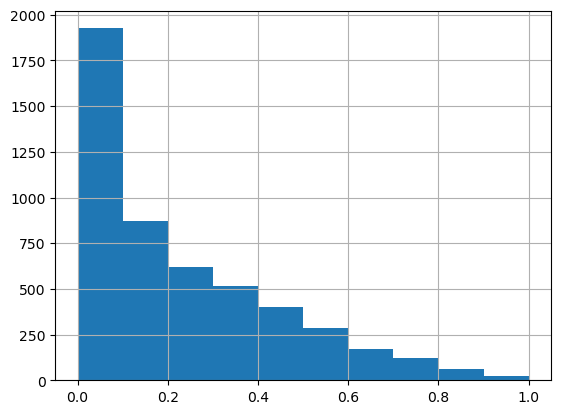

In [82]:
#look at histogram of toxic probability for non-toxic plants
df_nontoxic_final['toxic_probability'].hist()

<Axes: >

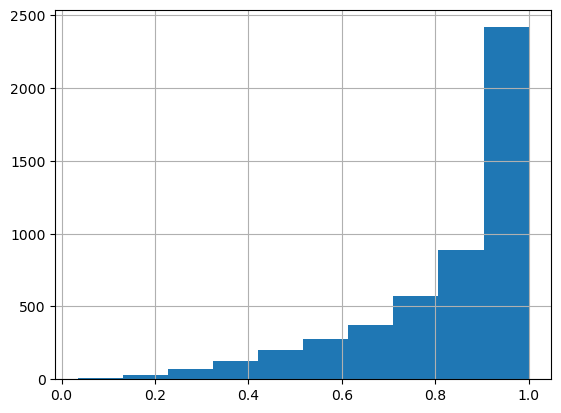

In [83]:
#look at histogram of toxic probability for toxic plants
df_toxic_final['toxic_probability'].hist()

In [57]:
#merge the dataframes into one
merged_predictions = pd.concat([df_toxic_final, df_nontoxic_final], ignore_index=True)

In [58]:
#create new column to merge on with features dataframe
merged_predictions["path"] = merged_predictions.apply(lambda row: os.path.join(row["source_folder"], row["filename"]), axis=1)

In [59]:
#import original dataframe with species name
plant_features=pd.read_csv('All_Plants_Features.csv.')

In [60]:
#normalize both paths to match
plant_features["path"] = plant_features["path"].apply(os.path.normpath)
merged_predictions["path"] = merged_predictions["path"].apply(os.path.normpath)

#merge dataframes on path column
merged_final = plant_features.merge(merged_predictions[["path", "prediction", "toxic_probability", "threshold"]],
    on="path", how="left")


In [61]:
#create Boolean column deliniating true/false predictions
merged_final["correct_prediction"] = (
    (merged_final["toxicity"] == 1) & (merged_final["prediction"] == "TOXIC")
) | (
    (merged_final["toxicity"] == 0) & (merged_final["prediction"] == "Non-Toxic")
)

In [63]:
merged_final.head()

,class_id,slang,scientific_name,toxicity,width,height,orientation,brightness,contrast,hue,saturation,path,prediction,toxic_probability,threshold,correct_prediction
0,0,Virginia creeper,Parthenocissus quinquefolia,0,335,500,portrait,0.082785,0.195098,0.081668,0.158307,tpc-imgs\nontoxic_images\000\000.jpg,Non-Toxic,0.163185,0.28,True
1,0,Virginia creeper,Parthenocissus quinquefolia,0,447,500,portrait,0.688486,0.194105,0.525180,0.412088,tpc-imgs\nontoxic_images\000\001.jpg,TOXIC,0.388864,0.28,False
2,0,Virginia creeper,Parthenocissus quinquefolia,0,333,500,portrait,0.501910,0.125857,0.549203,0.653836,tpc-imgs\nontoxic_images\000\002.jpg,TOXIC,0.306254,0.28,False
3,0,Virginia creeper,Parthenocissus quinquefolia,0,333,500,portrait,0.619444,0.171032,0.524528,0.494764,tpc-imgs\nontoxic_images\000\003.jpg,TOXIC,0.485347,0.28,False
4,0,Virginia creeper,Parthenocissus quinquefolia,0,375,500,portrait,0.577980,0.234796,0.232493,0.210950,tpc-imgs\nontoxic_images\000\004.jpg,Non-Toxic,0.003599,0.28,True


In [90]:
#group accuracy by species type
accuracy_by_species = (merged_final.groupby("slang").agg(
          accuracy=("correct_prediction", "mean"),
          count=("correct_prediction", "size")).reset_index())

print(accuracy_by_species)

                slang  accuracy  count
0            Bear Oak  0.732000   1000
1            Boxelder  0.571000   1000
2  Eastern Poison Ivy  0.990000   1000
3  Eastern Poison Oak  0.979036    954
4      Fragrant Sumac  0.503504    999
5  Jack-in-the-pulpit  0.828000   1000
6        Poison Sumac  0.990991    999
7    Virginia creeper  0.672000   1000
8  Western Poison Ivy  0.988000   1000
9  Western Poison Oak  0.986000   1000


Now we can test different plots to determine what visuals to use in the documentation and slide deck

In [65]:
import seaborn as sns

In [91]:
accuracy_by_species["toxicity"] = accuracy_by_species["slang"].str.contains("poison", case=False, na=False)\
                    .map({True: "toxic", False: "non-toxic"})

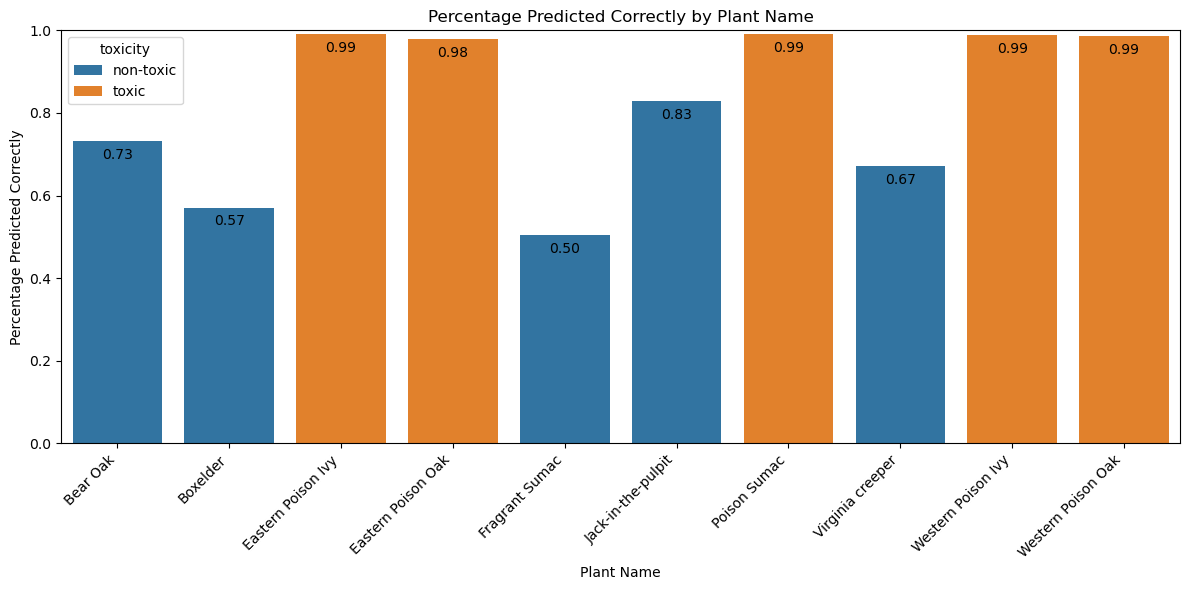

In [92]:
#add toxicity column to use for hue in the plot
accuracy_by_species["toxicity"] = accuracy_by_species["slang"].str.contains("poison", case=False, na=False)\
                    .map({True: "toxic", False: "non-toxic"})

#plot accuracy by species type
plt.figure(figsize=(12, 6))
ax =sns.barplot(data=accuracy_by_species, x="slang", y="accuracy", hue="toxicity")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.title("Percentage Predicted Correctly by Plant Name")
plt.ylabel("Percentage Predicted Correctly")
plt.xlabel("Plant Name")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=-15)
plt.tight_layout()
plt.show()

In [109]:
# False Negatives: true toxic (1) but predicted non-toxic (0)
df=merged_final

df["FN"] = ((df["toxicity"] == 1) & (df["prediction"] == 'Non-Toxic')).astype(int)

# False Positives: true non-toxic (0) but predicted toxic (1)
df["FP"] = ((df["toxicity"] == 0) & (df["prediction"] == 'TOXIC')).astype(int)

# Aggregate per species
errors_by_species = (
    df.groupby("slang").agg(
          FN=("FN", "sum"),
          FP=("FP", "sum"),
          total=("slang", "size")).reset_index())


In [110]:
print(errors_by_species)

                slang  FN   FP  total
0            Bear Oak   0  268   1000
1            Boxelder   0  429   1000
2  Eastern Poison Ivy  10    0   1000
3  Eastern Poison Oak  20    0    954
4      Fragrant Sumac   0  496    999
5  Jack-in-the-pulpit   0  172   1000
6        Poison Sumac   9    0    999
7    Virginia creeper   0  328   1000
8  Western Poison Ivy  12    0   1000
9  Western Poison Oak  14    0   1000


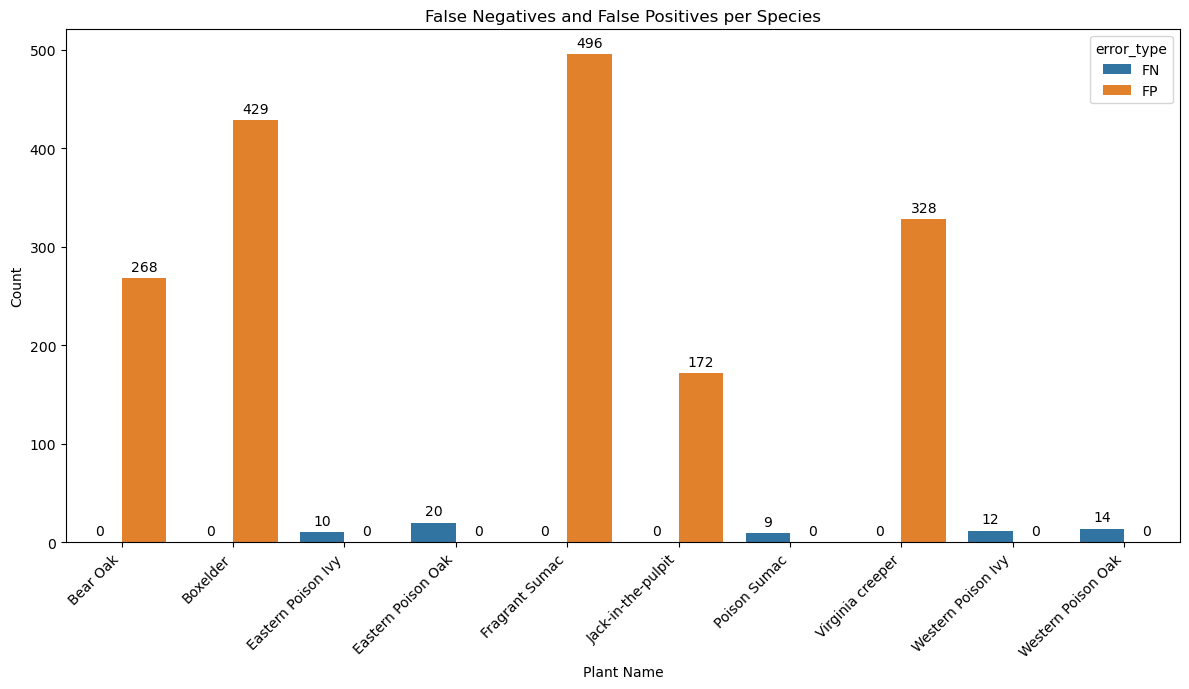

In [116]:
plt.figure(figsize=(12, 7))

errors_melted = errors_by_species.melt(
    id_vars=["slang", "total"],
    value_vars=["FN", "FP"],
    var_name="error_type",
    value_name="count"
)


ax = sns.barplot(
    data=errors_melted,
    x="slang",
    y="count",
    hue="error_type",
    
)

plt.xticks(rotation=45, ha="right")
plt.title("False Negatives and False Positives per Species")
plt.xlabel("Plant Name")
plt.ylabel("Count")

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()


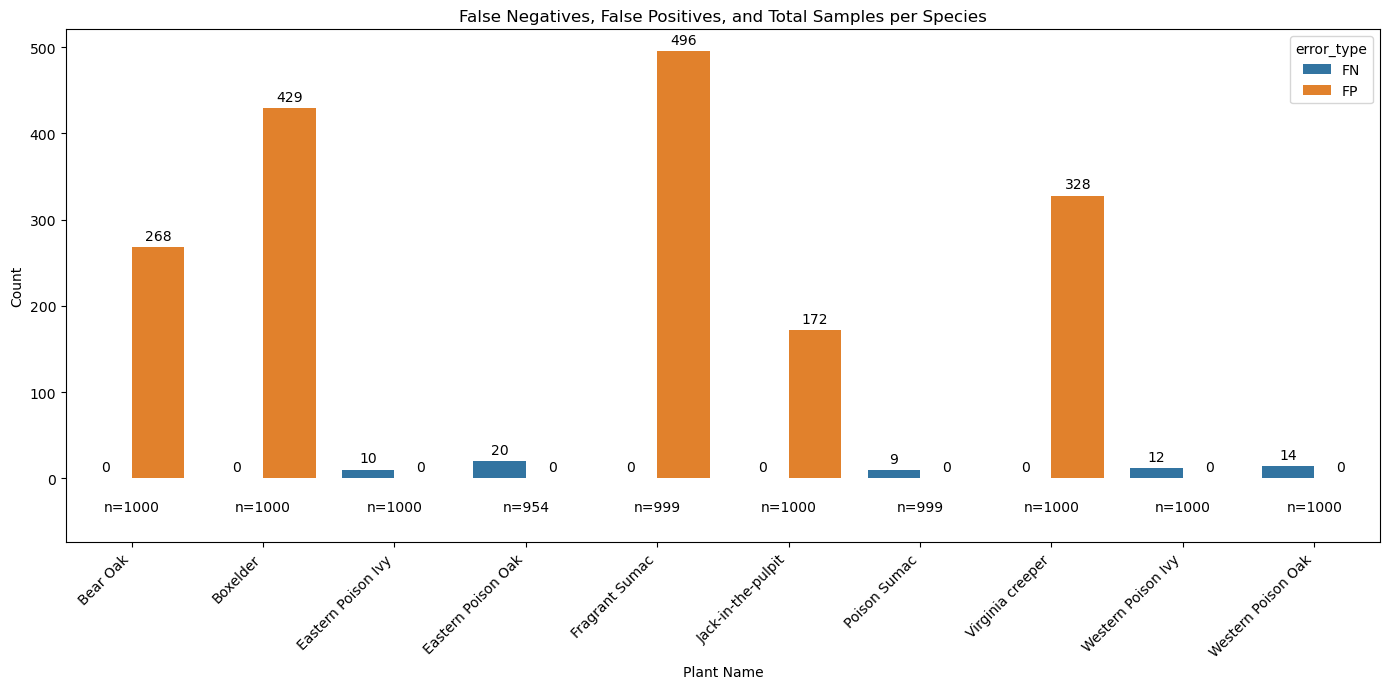

In [117]:
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=errors_melted,
    x="slang",
    y="count",
    hue="error_type",
    
)

# Add FN/FP labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

# Add total count as text below x‑axis labels
for i, row in errors_by_species.iterrows():
    ax.text(
        i, -max(errors_melted["count"])*0.05,  
        f"n={row['total']}",
        ha="center",
        va="top",
        fontsize=10,
        color="black"
    )

plt.xticks(rotation=45, ha="right")
plt.title("False Negatives, False Positives, and Total Samples per Species")
plt.xlabel("Plant Name")
plt.ylabel("Count")
plt.ylim(bottom=-max(errors_melted["count"])*0.15)
plt.tight_layout()
plt.show()


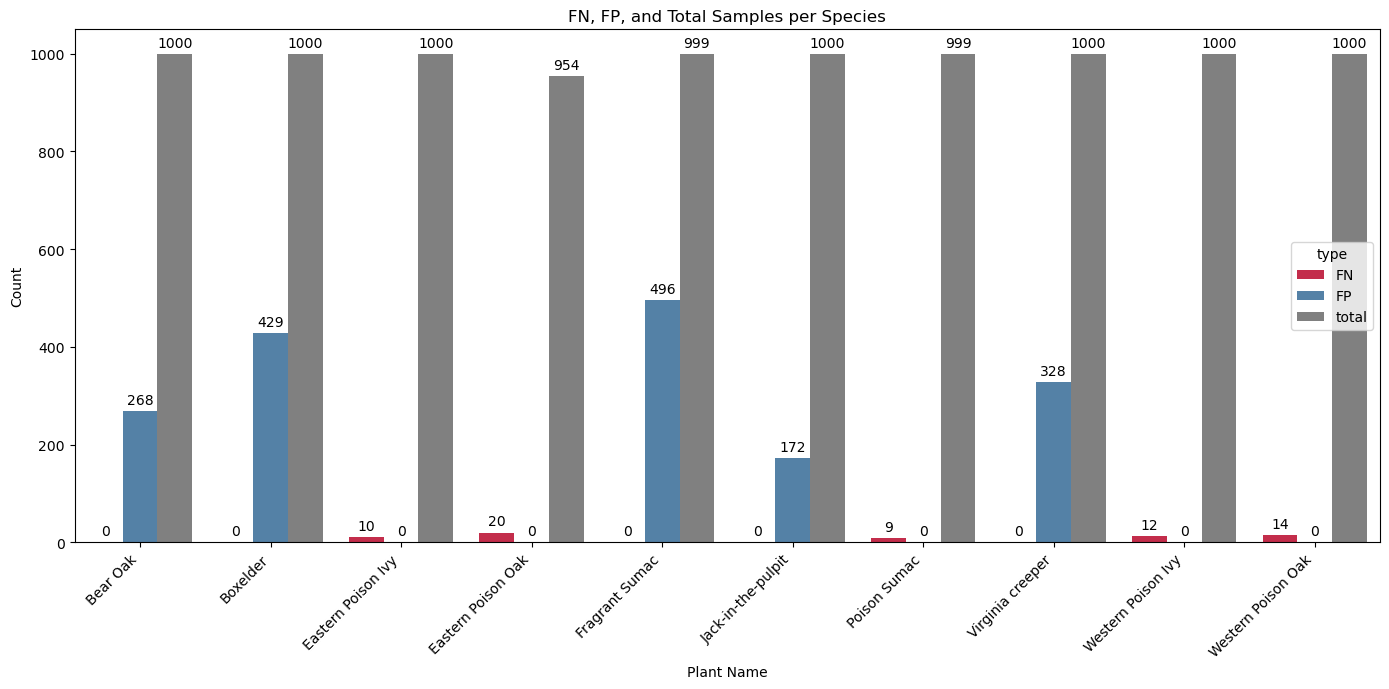

In [115]:
errors_melted2 = errors_by_species.melt(
    id_vars="slang",
    value_vars=["FN", "FP", "total"],
    var_name="type",
    value_name="count"
)

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=errors_melted2,
    x="slang",
    y="count",
    hue="type",
    palette={"FN": "crimson", "FP": "steelblue", "total": "gray"}
)

plt.xticks(rotation=45, ha="right")
plt.title("FN, FP, and Total Samples per Species")
plt.xlabel("Plant Name")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()


In [118]:
# correct_prediction is 1 for correct, 0 for incorrect

stats = (merged_final.groupby("slang").agg(
          correct=("correct_prediction", "sum"),
          total=("correct_prediction", "size")).reset_index())

stats["incorrect"] = stats["total"] - stats["correct"]
stats["pct_correct"] = stats["correct"] / stats["total"]
print(stats)

                slang  correct  total  incorrect  pct_correct
0            Bear Oak      732   1000        268     0.732000
1            Boxelder      571   1000        429     0.571000
2  Eastern Poison Ivy      990   1000         10     0.990000
3  Eastern Poison Oak      934    954         20     0.979036
4      Fragrant Sumac      503    999        496     0.503504
5  Jack-in-the-pulpit      828   1000        172     0.828000
6        Poison Sumac      990    999          9     0.990991
7    Virginia creeper      672   1000        328     0.672000
8  Western Poison Ivy      988   1000         12     0.988000
9  Western Poison Oak      986   1000         14     0.986000


In [119]:
plot_df = stats.melt(
    id_vars=["slang", "pct_correct"],
    value_vars=["correct", "incorrect"],
    var_name="type",
    value_name="count")


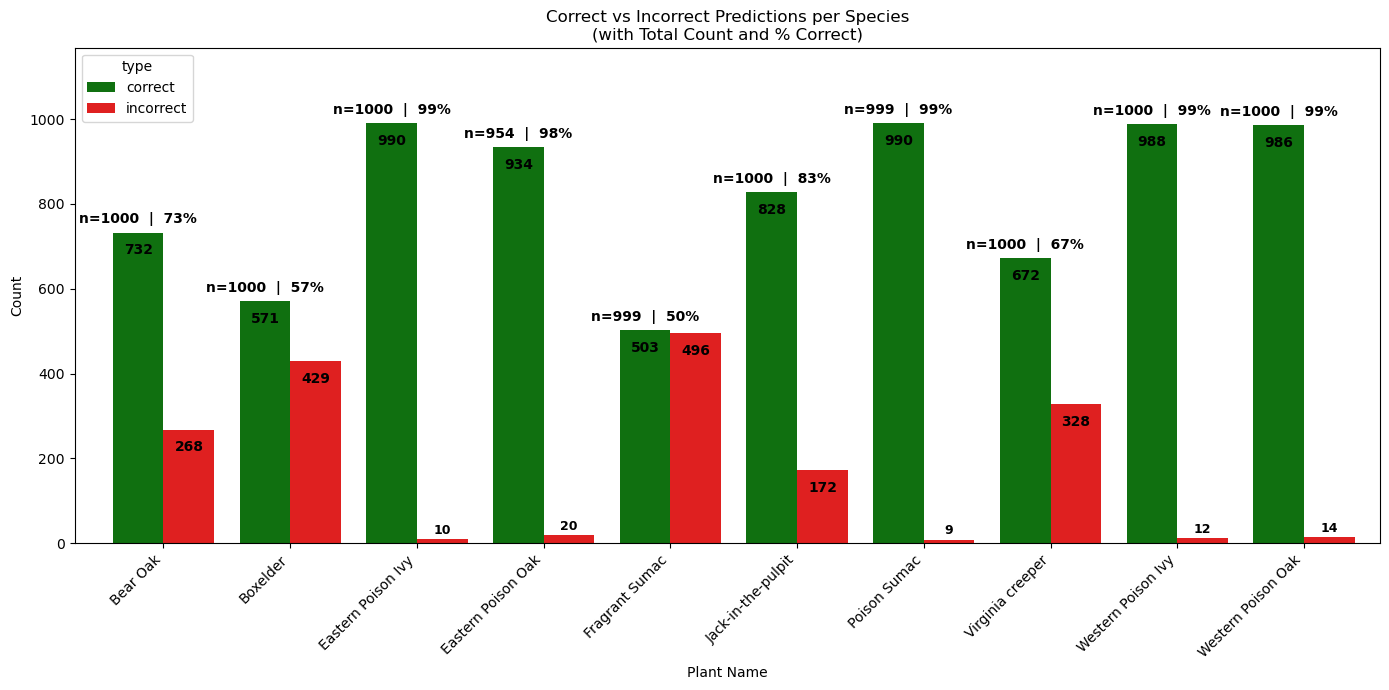

In [177]:
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=plot_df,
    x="slang",
    y="count",
    hue="type",
    palette={"correct": "green", "incorrect": "red"}
)

# Inside/outside labels for correct and incorrect counts
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 50:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height - 25,
                f"{int(height)}",
                ha="center", va="top",
                color="black", fontsize=10, fontweight="bold")
        else:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 5,
                f"{int(height)}",
                ha="center", va="bottom",
                color="black", fontsize=9, fontweight="bold")

# Total count and % correct above the green bar for each species
for i, row in stats.iterrows():
    green_bar_x = i - 0.2   # adjust if bars shift
    ax.text(
        green_bar_x,
        row["correct"] + 15,
        f"n={int(row['total'])}  |  {row['pct_correct']*100:.0f}%",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold", color="black")

# Extend y-axis for label headroom
ax.set_ylim(0, max(plot_df["count"]) * 1.18)

#Extend x-axis for label headroom
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min - 0.2, x_max + 0.1)

plt.xticks(rotation=45, ha="right")
plt.title("Correct vs Incorrect Predictions per Species\n(with Total Count and % Correct)")
plt.xlabel("Plant Name")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

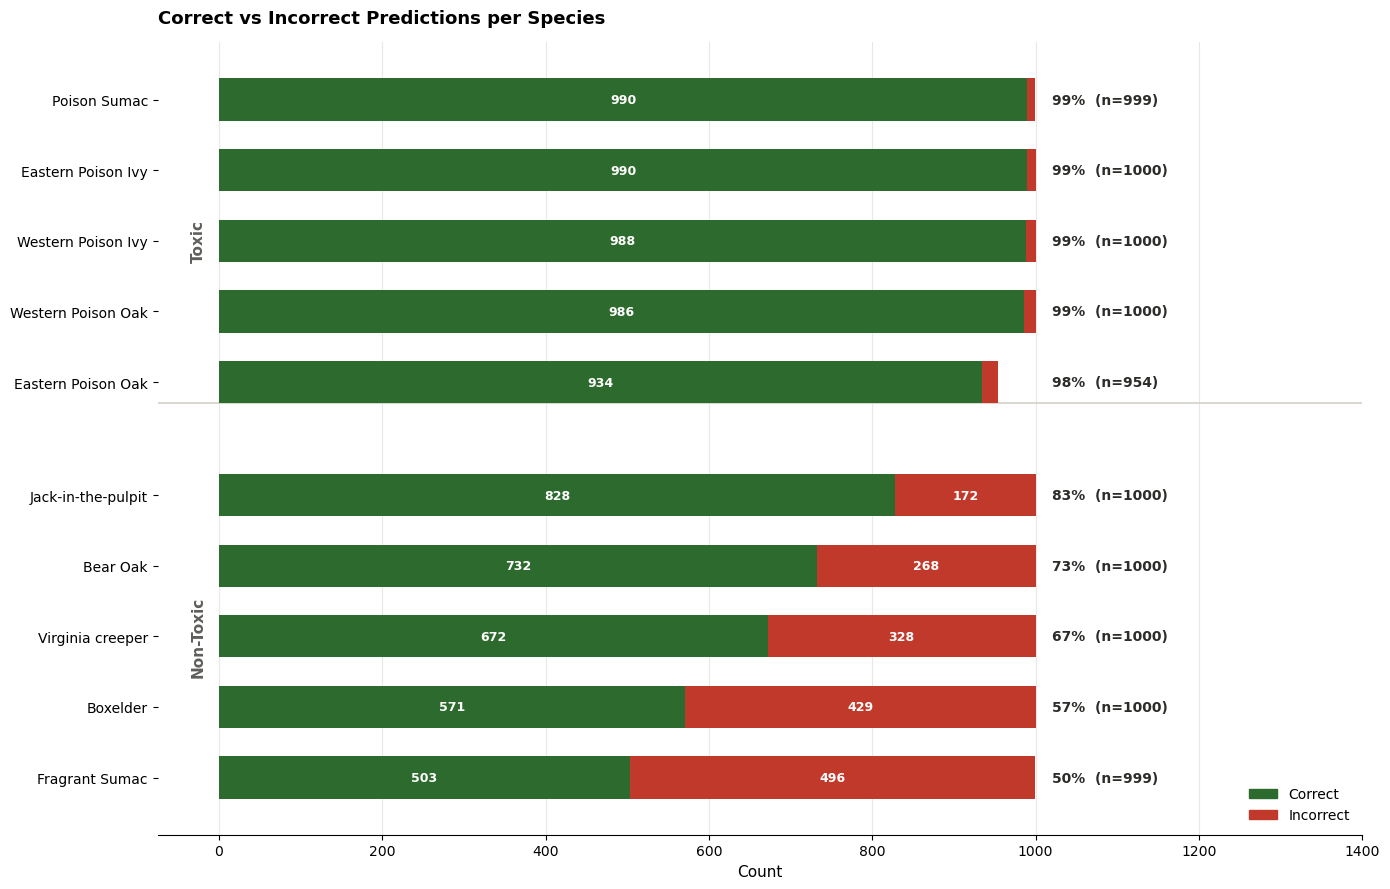

In [206]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Toxicity mapping
toxicity_map = {
    'Bear Oak': 'Non-Toxic', 'Boxelder': 'Non-Toxic',
    'Fragrant Sumac': 'Non-Toxic', 'Jack-in-the-pulpit': 'Non-Toxic',
    'Virginia creeper': 'Non-Toxic', 'Eastern Poison Ivy': 'Toxic',
    'Eastern Poison Oak': 'Toxic', 'Poison Sumac': 'Toxic',
    'Western Poison Ivy': 'Toxic', 'Western Poison Oak': 'Toxic'
}

stats['toxicity'] = stats['slang'].map(toxicity_map)

# Sort within each group by pct_correct ascending (worst at top)
nontoxic = (stats[stats['toxicity'] == 'Non-Toxic']
            .sort_values('pct_correct', ascending=True)
            .reset_index(drop=True))
toxic    = (stats[stats['toxicity'] == 'Toxic']
            .sort_values('pct_correct', ascending=True)
            .reset_index(drop=True))

ordered = pd.concat([nontoxic, pd.DataFrame([None]), toxic]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 9))

y_pos    = []
y_labels = []
y_tick   = 0
gap_y    = None

# Fixed x position for all % labels — just past the longest possible bar
max_total    = stats['total'].max()
label_x_fixed = max_total + 20   # all % labels start at same x

for _, row in ordered.iterrows():
    if row.isnull().all():
        gap_y = y_tick
        y_tick += 0.6
        continue

    y_pos.append(y_tick)
    y_labels.append(row['slang'])

    # Stacked bars
    ax.barh(y_tick, row['correct'],   height=0.6, color='#2d6a2d', zorder=2)
    ax.barh(y_tick, row['incorrect'], height=0.6, color='#c0392b',
            left=row['correct'], zorder=2)

    # Correct count inside green bar
    if row['correct'] > 60:
        ax.text(row['correct'] / 2, y_tick, f"{int(row['correct'])}",
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')

    # Incorrect count — always inside bar if wide enough, otherwise skip
    # (no outside label so it never overlaps the % column)
    if row['incorrect'] > 40:
        ax.text(row['correct'] + row['incorrect'] / 2, y_tick,
                f"{int(row['incorrect'])}",
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold')

    # % and total — all at the same fixed x position
    ax.text(label_x_fixed, y_tick,
            f"{row['pct_correct']*100:.0f}%  (n={int(row['total'])})",
            ha='left', va='center',
            fontsize=10, fontweight='bold', color='#2C2C2A')

    y_tick += 1

# Group labels — moved further left to avoid overlapping species names
nontoxic_ys = y_pos[:len(nontoxic)]
toxic_ys    = y_pos[len(nontoxic):]

ax.text(-25, np.mean(nontoxic_ys), 'Non-Toxic', ha='center', va='center',
        fontsize=11, fontweight='bold', color='#5F5E5A', rotation=90)
ax.text(-25, np.mean(toxic_ys),    'Toxic',     ha='center', va='center',
        fontsize=11, fontweight='bold', color='#5F5E5A', rotation=90)

# Divider line between groups
if gap_y:
    ax.axhline(gap_y + 0.3, color='#D3D1C7', linewidth=1.2, zorder=1)

# Axes formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels, fontsize=10)
ax.set_xlabel('Count', fontsize=11)

# x limits: left padding for group labels, right padding for % labels
ax.set_xlim(-75, max_total * 1.40)

ax.set_title('Correct vs Incorrect Predictions per Species',
             fontsize=13, fontweight='bold', pad=14, loc='left')

# Grid
ax.xaxis.grid(True, color='#E8E8E8', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)

# Legend
legend = [
    mpatches.Patch(color='#2d6a2d', label='Correct'),
    mpatches.Patch(color='#c0392b', label='Incorrect')
]
ax.legend(handles=legend, loc='lower right', frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('horizontal_stacked_bar.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()